# Data Exploration

In [65]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
# load data 
def load_data(file_path: str) -> pd.DataFrame | None:
    try:
        df = pd.read_csv(file_path)
        return df
    except FileNotFoundError:
        print("Error: file not found with given path.")

In [67]:
# load data
df: pd.DataFrame = load_data("/Users/williammahnke/Desktop/Revature/team3_assignment10/ai_student_impact_dataset (1).csv")  # pyright: ignore[reportAssignmentType]

In [68]:
# first look
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [69]:
# info 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

## Notes for Cleaning Data & Missing Values
* no missing values for any of the columns - might explore what to do if this wasn't the case
* no repeat ids 
* five majors - no weird names to map
    - could talk about mapping any weird values to corrent name, or if necessary collapsing smaller major counts to an "other" category
* five grade levels - no weird values to map
    - could do something similar to major column
* no GPA values outside 1.0-4.0 range
* burnout risk values are fine, nothing needed 
* anxiety levels are fine, nothing needed
* skill retenion values well defined
    - potentially convert to float to represent percentage better (probably fine as is)
* no weird institutional policy values
    - map underscores to spaces 
* no weird AI dependency values
* no bad traditional hour values
* no bad AI hour values
* no weird use case values, did map underscores to spaces for some values (slashes are fine)
* no weird prompt engineering values
* distriubtion of tool diversity fine
* distriubtion of paid sub fine

## Exploration

In [70]:
# number of unqiue ids, make sure no repeats
print("=" * 50)
print(f"Number of unique ids: {df["Student_ID"].nunique()}. Expected number of unqiue ids: {df.shape[0]}")
print("=" * 50)

# look at majors, see if any need mapping
print(df["Major_Category"].value_counts())
print("=" * 50)

# look at years
print(df["Year_of_Study"].value_counts())
print("=" * 50)

# look at distirbution of pre semester GPA
gpa_under_1 = df.loc[df["Pre_Semester_GPA"] < 1.0]["Pre_Semester_GPA"].count()
print(f"# of pre-semester GPAs below 1.0: {gpa_under_1}")

gpa_over_4 = df.loc[df["Pre_Semester_GPA"] > 4.0]["Pre_Semester_GPA"].count()
print(f"# of pre-semester GPAs above 4.0: {gpa_over_4}")
print("=" * 50)

# look at distirbution of post semester GPA
gpa_under_1 = df.loc[df["Post_Semester_GPA"] < 1.0]["Post_Semester_GPA"].count()
print(f"# of post-semester GPAs below 1.0: {gpa_under_1}")
gpa_over_4 = df.loc[df["Post_Semester_GPA"] > 4.0]["Post_Semester_GPA"].count()
print(f"# of post-semester GPAs above 4.0: {gpa_over_4}")
print("=" * 50)

# weekly AI hours
neg_ai_hours = df.loc[df["Weekly_GenAI_Hours"] < 0, "Weekly_GenAI_Hours"].count()
print(f"Number of students with negative AI use hours: {neg_ai_hours}")
print("=" * 50)

Number of unique ids: 50000. Expected number of unqiue ids: 50000
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64
# of pre-semester GPAs below 1.0: 0
# of pre-semester GPAs above 4.0: 0
# of post-semester GPAs below 1.0: 0
# of post-semester GPAs above 4.0: 0
Number of students with negative AI use hours: 0


In [76]:
# checking distribution for use case 
print("=" * 50)
print(df["Primary_Use_Case"].value_counts())
print("=" * 50)

# prompt engineering distribution
print(df["Prompt_Engineering_Skill"].value_counts())
print("=" * 50)

# tool diversity
print(df["Tool_Diversity"].value_counts())
print("=" * 50)

# paid sub distribution
print(df["Paid_Subscription"].value_counts())
print("=" * 50)

Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing Reading           8633
Direct Answer Generation      6340
Name: count, dtype: int64
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64
Tool_Diversity
3    16926
2    11830
1     8141
4     8081
5     5022
Name: count, dtype: int64
Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64


In [72]:
# make sure study hours aren't less than zero
print("=" * 50)
neg_study_hours = df.loc[df["Traditional_Study_Hours"] < 0]["Traditional_Study_Hours"].count()
print(f"# of students with negative study hours: {neg_study_hours}")
print("=" * 50)

# distribution of perceived AI dependency
print(df["Perceived_AI_Dependency"].value_counts())
print("=" * 50)

# check values for institutional policy
print(df["Institutional_Policy"].value_counts())
print("=" * 50)

# distirubtion of anxiety levels
print(df.Anxiety_Level_During_Exams.value_counts())
print("=" * 50)

# of students with negative study hours: 0
Perceived_AI_Dependency
3     10478
4      9934
2      8874
1      7303
5      6745
6      3521
7      1722
8       855
9       378
10      190
Name: count, dtype: int64
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64
Anxiety_Level_During_Exams
4     8749
5     8222
3     7806
6     6107
2     5752
1     5655
7     3850
8     2088
9     1151
10     620
Name: count, dtype: int64


In [73]:
# check skill retention is well define (0-100)
print("=" * 50)
retention_under_0 = df.loc[df["Skill_Retention_Score"] < 0]["Skill_Retention_Score"].count()
retention_over_100 = df.loc[df["Skill_Retention_Score"] > 100]["Skill_Retention_Score"].count()
print(f"# of students with retention % under 0: {retention_under_0}")
print(f"# of students with retention % over 100: {retention_over_100}")
print("=" * 50)
# look at Burnout values, see if mapping is needed
print(df.Burnout_Risk_Level.value_counts())
print("=" * 50)

# of students with retention % under 0: 0
# of students with retention % over 100: 0
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


## Cleaning

* replace underscores with spaces for some string values in `Primary_Use_Case` and `Institutional_Policy`
* round GPA columns to decimal places 

In [75]:
# replace underscores with spaces for two columns
df["Primary_Use_Case"] = df["Primary_Use_Case"].str.replace("_", " ")
df["Institutional_Policy"] = df["Institutional_Policy"].str.replace("_", " ")

# round GPA columns to two decimal places 
df[["Pre_Semester_GPA", "Post_Semester_GPA"]] = df[["Pre_Semester_GPA", "Post_Semester_GPA"]].round(2)

In [ ]:
# checking distribution for use case with string change
print("=" * 50)
print(df["Primary_Use_Case"].value_counts())
print("=" * 50)

# check values for institutional policy with string change
print(df["Institutional_Policy"].value_counts())
print("=" * 50)

## Plots

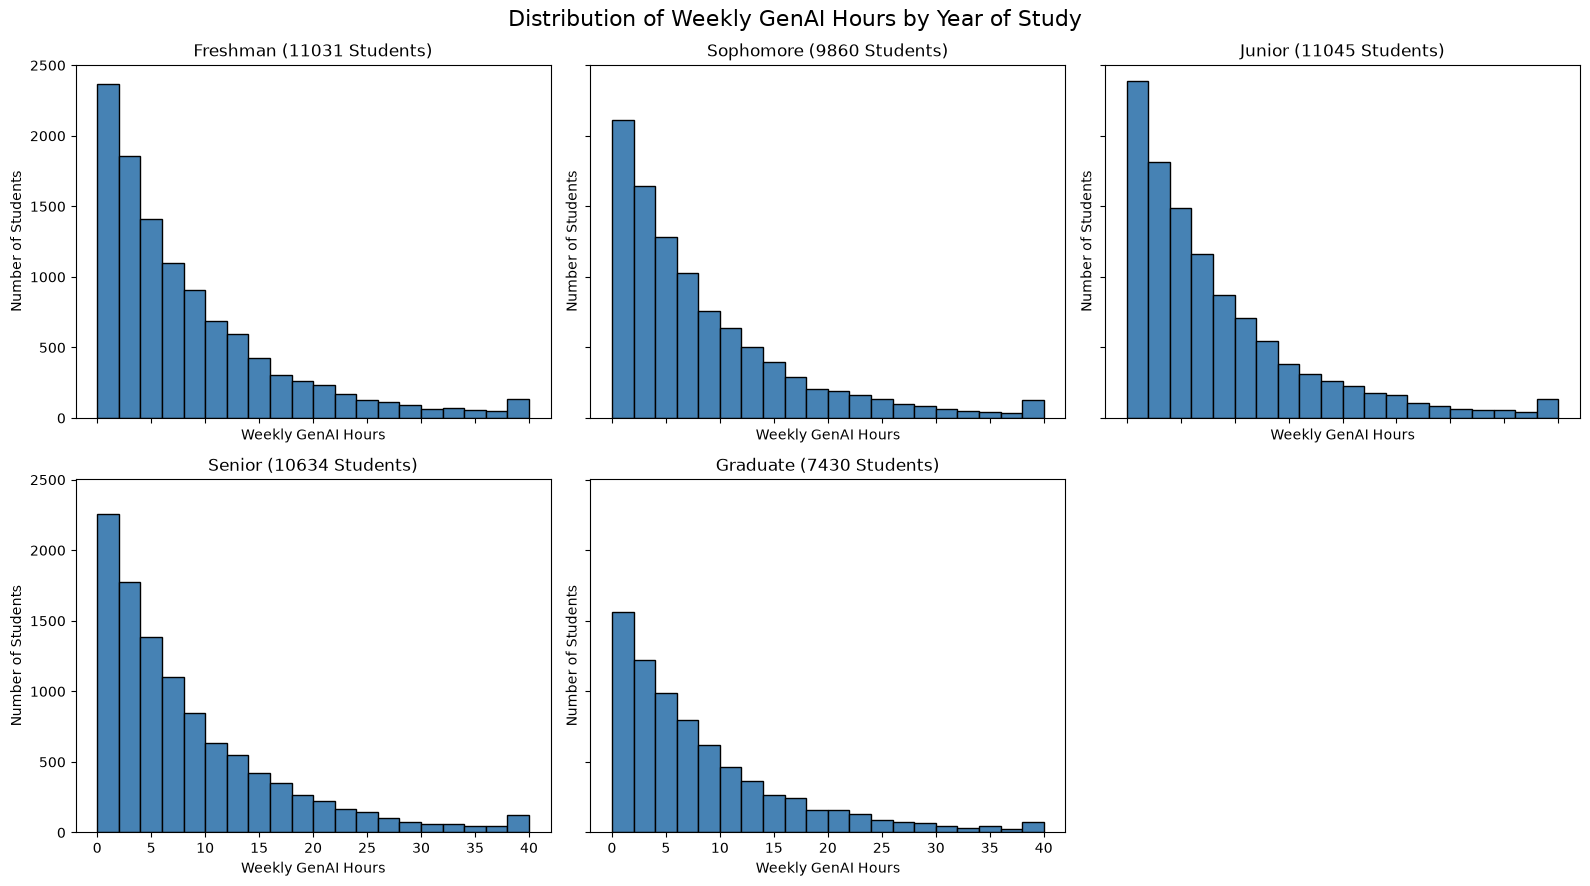

In [79]:
# histograms of Weekly_GenAI_Hours for each Year_of_Study value
years = ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]

# shared bins (2-hour width) so distributions are comparable across years
max_hours = df["Weekly_GenAI_Hours"].max()
bins = np.arange(0, np.ceil(max_hours) + 2, 2)  # pyright: ignore[reportCallIssue, reportArgumentType]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, year in zip(axes, years):
    subset = df.loc[df["Year_of_Study"] == year, "Weekly_GenAI_Hours"]
    ax.hist(subset, bins=bins, color="steelblue", edgecolor="black")
    ax.set_title(f"{year} ({subset.shape[0]} Students)")
    ax.set_xlabel("Weekly GenAI Hours")
    ax.set_ylabel("Number of Students")
    # force x tick labels on every subplot (sharex hides them on the top rows)
    ax.tick_params(labelbottom=True)

# hide any unused subplot axes
for ax in axes[len(years):]:
    ax.set_visible(False)

fig.suptitle("Distribution of Weekly GenAI Hours by Year of Study", fontsize=16)
fig.tight_layout()
plt.show()

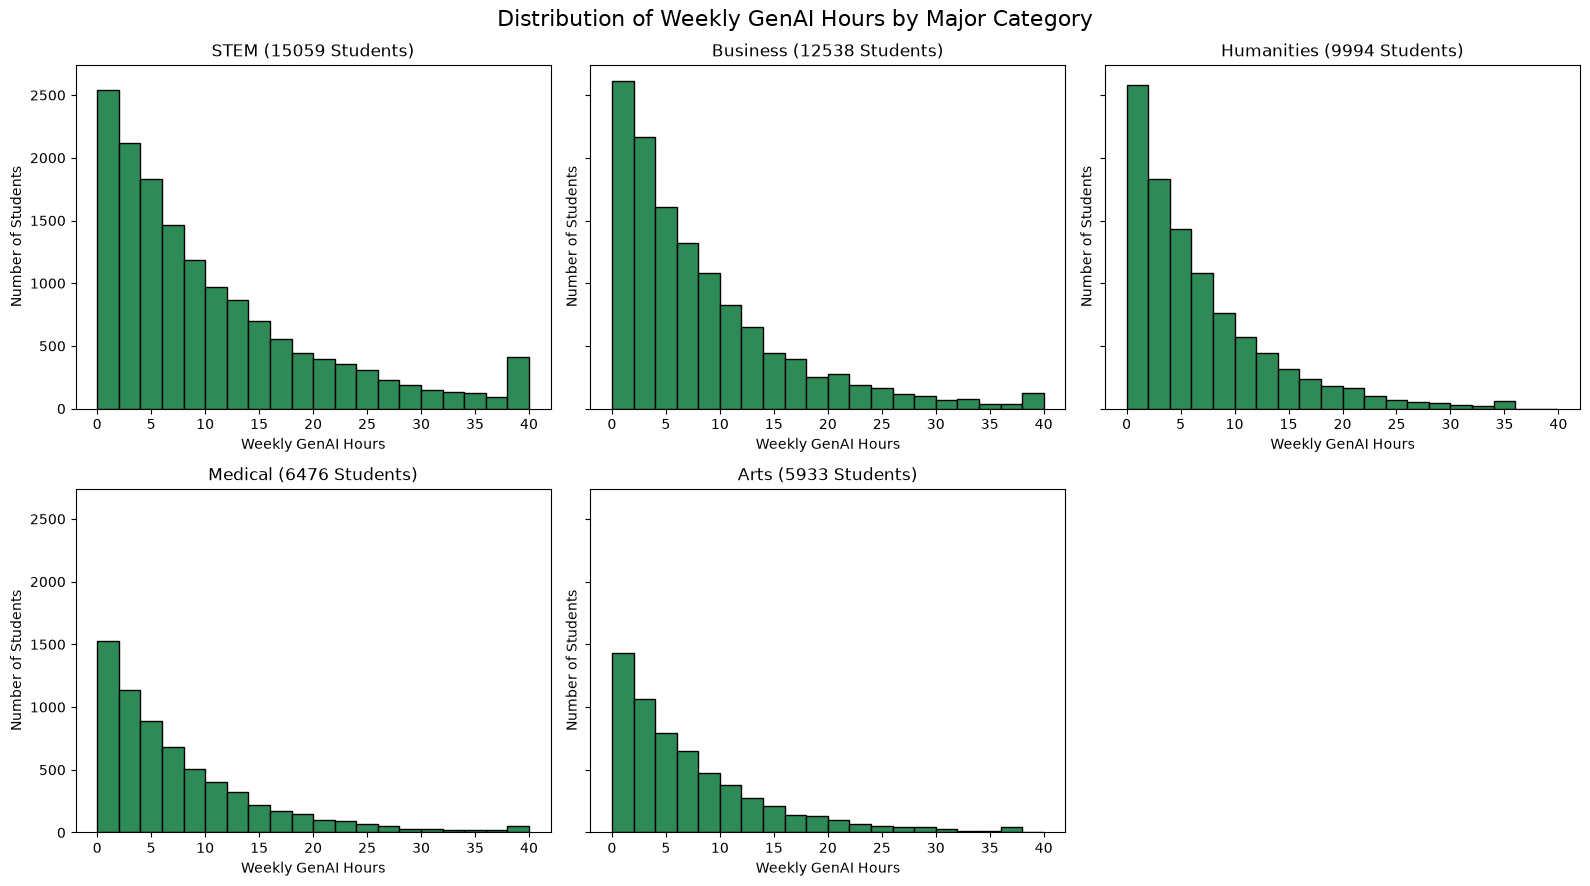

In [80]:
# histograms of Weekly_GenAI_Hours for each Major_Category value
majors = ["STEM", "Business", "Humanities", "Medical", "Arts"]

# shared bins (2-hour width) so distributions are comparable across majors
max_hours = df["Weekly_GenAI_Hours"].max()
bins = np.arange(0, np.ceil(max_hours) + 2, 2)  # pyright: ignore[reportCallIssue, reportArgumentType]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, major in zip(axes, majors):
    subset = df.loc[df["Major_Category"] == major, "Weekly_GenAI_Hours"]
    ax.hist(subset, bins=bins, color="seagreen", edgecolor="black")
    ax.set_title(f"{major} ({subset.shape[0]} Students)")
    ax.set_xlabel("Weekly GenAI Hours")
    ax.set_ylabel("Number of Students")
    # force x tick labels on every subplot (sharex hides them on the top rows)
    ax.tick_params(labelbottom=True)

# hide any unused subplot axes
for ax in axes[len(majors):]:
    ax.set_visible(False)

fig.suptitle("Distribution of Weekly GenAI Hours by Major Category", fontsize=16)
fig.tight_layout()
plt.show()